# UTS PREDIKSI MODERN & MACHINE LEARNING
## Experiment Challenge: Credit Default Prediction

**Nama:** Salfa Putri Lestari

**NIM:** 2404220002

**Prodi:** Statistika dan Sains Data

### Dataset
Default of Credit Card Clients Dataset

### Target
`default.payment.next.month`
- 0 = Tidak mengalami default
- 1 = Mengalami default

In [ ]:
# Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Library berhasil diimport.")

Library berhasil diimport.


## Eksperimen 0

In [ ]:
df = pd.read_csv ("/content/Credit Card_PMML.csv")

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
# Melihat dimensi dataset
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 30000
Jumlah kolom: 25


In [ ]:
# Melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [ ]:
# Menampilkan seluruh nama variabel
print("Daftar variabel:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Daftar variabel:
1. ID
2. LIMIT_BAL
3. SEX
4. EDUCATION
5. MARRIAGE
6. AGE
7. PAY_0
8. PAY_2
9. PAY_3
10. PAY_4
11. PAY_5
12. PAY_6
13. BILL_AMT1
14. BILL_AMT2
15. BILL_AMT3
16. BILL_AMT4
17. BILL_AMT5
18. BILL_AMT6
19. PAY_AMT1
20. PAY_AMT2
21. PAY_AMT3
22. PAY_AMT4
23. PAY_AMT5
24. PAY_AMT6
25. default.payment.next.month


In [ ]:
# Menentukan variabel target
target = "default.payment.next.month"

print("Variabel target:", target)

Variabel target: default.payment.next.month


### Pemeriksaan Missing Value

Pemeriksaan missing value dilakukan untuk mengetahui apakah terdapat data yang kosong pada setiap variabel. Pemeriksaan ini penting sebelum proses pemodelan agar tidak terjadi masalah pada tahap preprocessing dan training model.

In [ ]:
# Memeriksa jumlah missing value pada setiap variabel

missing_value = df.isnull().sum()

print("Jumlah missing value setiap variabel:")
print(missing_value)

Jumlah missing value setiap variabel:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


In [ ]:
# Menampilkan hanya variabel yang memiliki missing value

missing_value[missing_value > 0]


,0


### Pemeriksaan Duplicate

Pemeriksaan duplicate dilakukan untuk mengetahui apakah terdapat observasi yang tercatat lebih dari satu kali dalam dataset.

In [ ]:
# Memeriksa jumlah data duplicate

jumlah_duplicate = df.duplicated().sum()

print("Jumlah data duplicate:", jumlah_duplicate)

Jumlah data duplicate: 0


In [ ]:
# Persentase data duplicate

persentase_duplicate = (jumlah_duplicate / len(df)) * 100

print(f"Persentase duplicate: {persentase_duplicate:.2f}%")

Persentase duplicate: 0.00%


### Pemeriksaan Nilai yang Tidak Sesuai atau Tidak Wajar

Pemeriksaan dilakukan dengan melihat statistik deskriptif setiap variabel numerik untuk mengidentifikasi nilai minimum, maksimum, rata-rata, dan kemungkinan nilai yang berada di luar rentang yang seharusnya.

In [ ]:
# Statistik deskriptif seluruh variabel numerik

df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [ ]:
# Melihat nilai unik beberapa variabel kategorikal

categorical_check = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "default.payment.next.month"
]

for col in categorical_check:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

default.payment.next.month
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


### Distribusi Variabel Target

Distribusi target diperiksa untuk mengetahui jumlah dan proporsi nasabah yang mengalami default dan yang tidak mengalami default.

In [ ]:
# Menghitung jumlah masing-masing kelas target

target_count = df[target].value_counts().sort_index()

print("Jumlah masing-masing kelas:")
print(target_count)

Jumlah masing-masing kelas:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


In [ ]:
# Menghitung persentase masing-masing kelas target

target_percentage = df[target].value_counts(normalize=True).sort_index() * 100

print("Persentase masing-masing kelas:")
print(target_percentage.round(2))

Persentase masing-masing kelas:
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


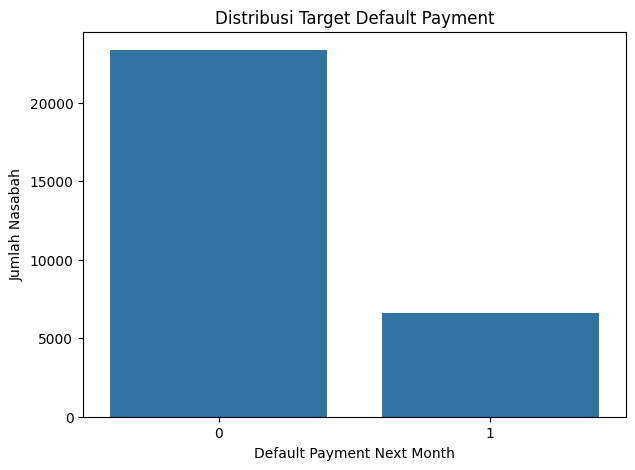

In [ ]:
# Visualisasi distribusi target

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=target
)

plt.title("Distribusi Target Default Payment")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Jumlah Nasabah")

plt.show()

In [ ]:
# Membuat salinan dataset untuk proses data preparation
df_clean = df.copy()

# Menggabungkan kategori EDUCATION 0, 5, dan 6 ke kategori 4
df_clean["EDUCATION"] = df_clean["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

# Memeriksa kembali nilai EDUCATION
print("Nilai EDUCATION setelah cleaning:")
print(df_clean["EDUCATION"].value_counts().sort_index())

Nilai EDUCATION setelah cleaning:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64


In [ ]:
# Menggabungkan kategori MARRIAGE 0 ke kategori 3 (Other)
df_clean["MARRIAGE"] = df_clean["MARRIAGE"].replace({
    0: 3
})

# Memeriksa kembali nilai MARRIAGE
print("Nilai MARRIAGE setelah cleaning:")
print(df_clean["MARRIAGE"].value_counts().sort_index())

Nilai MARRIAGE setelah cleaning:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [ ]:
# Pemeriksaan ulang kategori setelah cleaning

print("=== EDUCATION ===")
print(df_clean["EDUCATION"].value_counts().sort_index())

print("\n=== MARRIAGE ===")
print(df_clean["MARRIAGE"].value_counts().sort_index())

print("\n=== SEX ===")
print(df_clean["SEX"].value_counts().sort_index())

=== EDUCATION ===
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

=== MARRIAGE ===
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

=== SEX ===
SEX
1    11888
2    18112
Name: count, dtype: int64


In [ ]:
print("Jumlah baris sebelum cleaning :", len(df))
print("Jumlah baris setelah cleaning :", len(df_clean))

Jumlah baris sebelum cleaning : 30000
Jumlah baris setelah cleaning : 30000


In [ ]:
print("Total missing value setelah cleaning:",
      df_clean.isnull().sum().sum())

Total missing value setelah cleaning: 0


In [ ]:
# Menentukan target
target = "default.payment.next.month"

# Memisahkan predictor dan target
X = df_clean.drop(columns=[target])
y = df_clean[target]

print("Jumlah predictor:", X.shape[1])
print("Jumlah observasi:", X.shape[0])
print("Nama target:", target)

Jumlah predictor: 24
Jumlah observasi: 30000
Nama target: default.payment.next.month


In [ ]:
# Menghapus variabel ID dari predictor
X = X.drop(columns=["ID"])

print("Jumlah predictor setelah ID dihapus:", X.shape[1])
print("\nDaftar predictor:")
print(X.columns.tolist())

Jumlah predictor setelah ID dihapus: 23

Daftar predictor:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [ ]:
# Memastikan target tidak terdapat dalam predictor
print("Apakah target masih terdapat pada X?", target in X.columns)
print("Nama target:", y.name)

Apakah target masih terdapat pada X? False
Nama target: default.payment.next.month


In [ ]:
# Membagi data menjadi data training dan data testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (24000, 23)
Ukuran X_test : (6000, 23)
Ukuran y_train: (24000,)
Ukuran y_test : (6000,)


In [ ]:
# Membandingkan distribusi target pada data keseluruhan,
# training, dan testing

print("Distribusi target - Data keseluruhan:")
print(y.value_counts(normalize=True).sort_index() * 100)

print("\nDistribusi target - Data training:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print("\nDistribusi target - Data testing:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

Distribusi target - Data keseluruhan:
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64

Distribusi target - Data training:
default.payment.next.month
0    77.879167
1    22.120833
Name: proportion, dtype: float64

Distribusi target - Data testing:
default.payment.next.month
0    77.883333
1    22.116667
Name: proportion, dtype: float64


### Pencegahan Data Leakage

Train-test split dilakukan sebelum proses training dan preprocessing yang membutuhkan proses fitting. Pada tahap pemodelan, preprocessing seperti feature scaling akan diterapkan menggunakan Pipeline sehingga parameter preprocessing hanya dipelajari dari data training dan tidak menggunakan informasi dari data testing.

In [ ]:
# Melihat tipe data predictor

print("Tipe data predictor:")
print(X.dtypes)

Tipe data predictor:
LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_0          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
dtype: object


In [ ]:
# Memisahkan variabel berdasarkan tipe data

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Jumlah variabel numerik:", len(numeric_features))
print("Variabel numerik:")
print(numeric_features)

print("\nJumlah variabel kategorikal:", len(categorical_features))
print("Variabel kategorikal:")
print(categorical_features)

Jumlah variabel numerik: 23
Variabel numerik:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Jumlah variabel kategorikal: 0
Variabel kategorikal:
[]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

print("StandardScaler berhasil dibuat.")

StandardScaler berhasil dibuat.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessing_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=1000))
])

print("Pipeline preprocessing berhasil dibuat.")

Pipeline preprocessing berhasil dibuat.


### Keputusan Preprocessing

Berdasarkan hasil pemeriksaan data, tidak terdapat missing value maupun duplicate sehingga tidak diperlukan imputasi atau penghapusan data. Nilai kategori yang tidak terdokumentasi pada variabel EDUCATION dan MARRIAGE telah disesuaikan ke kategori lainnya.

Untuk pemodelan Logistic Regression, digunakan StandardScaler untuk menyamakan skala predictor. Preprocessing diterapkan menggunakan Pipeline agar proses scaling hanya memanfaatkan data training dan mencegah data leakage.

## EXPERIMENT 1 — BASELINE MODEL

In [ ]:
# Import Library
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [ ]:
# Membuat 5-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross Validation: 5-Fold Stratified Cross Validation")

Cross Validation: 5-Fold Stratified Cross Validation


In [ ]:
# Membuat Model Logistic Regression Baseline
baseline_model = LogisticRegression(max_iter=1000)

print(baseline_model)

LogisticRegression(max_iter=1000)


In [ ]:
# Melakukan 5-Fold Cross Validation
cv_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("F1-score setiap fold:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nRata-rata CV F1-score: {cv_scores.mean():.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

F1-score setiap fold:
Fold 1: 0.2752
Fold 2: 0.3893
Fold 3: 0.3881
Fold 4: 0.3473
Fold 5: 0.2834

Rata-rata CV F1-score: 0.3367


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Training Model pada Data Training
baseline_model.fit(X_train, y_train)

print("Baseline Logistic Regression berhasil dilatih.")

Baseline Logistic Regression berhasil dilatih.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Prediksi Dataset
y_pred_baseline = baseline_model.predict(X_test)

print("Prediksi data test berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_baseline))

Prediksi data test berhasil dilakukan.
Jumlah data yang diprediksi: 6000


In [ ]:
# Menghitung Accuracy, Precision, Recall, dan F1-score
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline)

print("=== Evaluasi Baseline Logistic Regression ===")
print(f"Accuracy  : {accuracy_baseline:.4f}")
print(f"Precision : {precision_baseline:.4f}")
print(f"Recall    : {recall_baseline:.4f}")
print(f"F1-score  : {f1_baseline:.4f}")

=== Evaluasi Baseline Logistic Regression ===
Accuracy  : 0.8082
Precision : 0.6648
Recall    : 0.2675
F1-score  : 0.3815


In [ ]:
# Tabel Hasil Experiment 1
hasil_exp1 = pd.DataFrame({
    "Experiment": ["Experiment 1"],
    "Model": ["Logistic Regression Baseline"],
    "CV F1": [cv_scores.mean()],
    "Test Accuracy": [accuracy_baseline],
    "Test Precision": [precision_baseline],
    "Test Recall": [recall_baseline],
    "Test F1": [f1_baseline]
})

hasil_exp1

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Experiment 1,Logistic Regression Baseline,0.336663,0.808167,0.664794,0.267521,0.381515


### Interpretasi Experiment 1

Model Logistic Regression baseline menghasilkan rata-rata F1-score sebesar **0,336663** berdasarkan 5-fold Cross Validation. Pada data test, model memperoleh Accuracy sebesar **0,808167**, Precision sebesar **0,664794**, Recall sebesar **0,267521**, dan F1-score sebesar **0,381515**.

Accuracy sebesar 0,808167 menunjukkan bahwa model mampu mengklasifikasikan sekitar 80,82% data test dengan benar. Namun, Recall hanya sebesar 0,267521, yang menunjukkan bahwa kemampuan model dalam mendeteksi nasabah yang mengalami default masih rendah. F1-score sebesar 0,381515 juga menunjukkan bahwa performa baseline masih belum optimal dalam mendeteksi kelas default.

Hasil ini digunakan sebagai **baseline** untuk dibandingkan dengan model setelah preprocessing pada Experiment 2.


## EXPERIMENT 2 — PREPROCESSING + LOGISTIC REGRESSION

In [ ]:
# Membuat Pipeline Prepocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

preprocessed_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=1000))
])

print(preprocessed_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic_regression', LogisticRegression(max_iter=1000))])


In [ ]:
# 5-Fold Cross Validation
cv_scores_exp2 = cross_val_score(
    preprocessed_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("F1-score setiap fold:")
for i, score in enumerate(cv_scores_exp2, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nRata-rata CV F1-score: {cv_scores_exp2.mean():.6f}")

F1-score setiap fold:
Fold 1: 0.3689
Fold 2: 0.3738
Fold 3: 0.3843
Fold 4: 0.3652
Fold 5: 0.3390

Rata-rata CV F1-score: 0.366218


In [ ]:
# Training Model
preprocessed_model.fit(X_train, y_train)

print("Model Logistic Regression dengan preprocessing berhasil dilatih.")

Model Logistic Regression dengan preprocessing berhasil dilatih.


In [ ]:
# Prediksi Data Test
y_pred_exp2 = preprocessed_model.predict(X_test)

print("Prediksi data test berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_exp2))

Prediksi data test berhasil dilakukan.
Jumlah data yang diprediksi: 6000


In [ ]:
# Evaluasi Model
accuracy_exp2 = accuracy_score(y_test, y_pred_exp2)
precision_exp2 = precision_score(y_test, y_pred_exp2)
recall_exp2 = recall_score(y_test, y_pred_exp2)
f1_exp2 = f1_score(y_test, y_pred_exp2)

print("=== Evaluasi Experiment 2 ===")
print(f"Accuracy  : {accuracy_exp2:.6f}")
print(f"Precision : {precision_exp2:.6f}")
print(f"Recall    : {recall_exp2:.6f}")
print(f"F1-score  : {f1_exp2:.6f}")

=== Evaluasi Experiment 2 ===
Accuracy  : 0.808333
Precision : 0.690323
Recall    : 0.241899
F1-score  : 0.358259


In [ ]:
# Tabel Hasil Experiment 2
hasil_exp2 = pd.DataFrame({
    "Experiment": ["Experiment 2"],
    "Model": ["StandardScaler + Logistic Regression"],
    "CV F1": [cv_scores_exp2.mean()],
    "Test Accuracy": [accuracy_exp2],
    "Test Precision": [precision_exp2],
    "Test Recall": [recall_exp2],
    "Test F1": [f1_exp2]
})

hasil_exp2

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Experiment 2,StandardScaler + Logistic Regression,0.366218,0.808333,0.690323,0.241899,0.358259


In [ ]:
# Perbandingan Experiment 1 dan 2
perbandingan_exp1_exp2 = pd.concat(
    [hasil_exp1, hasil_exp2],
    ignore_index=True
)

perbandingan_exp1_exp2

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Experiment 1,Logistic Regression Baseline,0.336663,0.808167,0.664794,0.267521,0.381515
1,Experiment 2,StandardScaler + Logistic Regression,0.366218,0.808333,0.690323,0.241899,0.358259


### Interpretasi Experiment 2

Pada Experiment 2, dilakukan preprocessing menggunakan StandardScaler sebelum membangun model Logistic Regression. Hasil 5-fold Cross Validation menunjukkan rata-rata CV F1-score sebesar **0,366218**, meningkat dibandingkan Experiment 1 sebesar **0,336663**.

Pada data test, model memperoleh Accuracy sebesar **0,808333**, Precision sebesar **0,690323**, Recall sebesar **0,241899**, dan F1-score sebesar **0,358259**. Dibandingkan dengan baseline, Accuracy dan Precision mengalami sedikit peningkatan, sedangkan Recall dan F1-score mengalami penurunan.

Karena F1-score merupakan metrik utama dalam evaluasi, preprocessing menggunakan StandardScaler **belum meningkatkan performa Logistic Regression pada data test**. Meskipun nilai CV F1 meningkat, nilai Test F1 turun dari **0,381515 menjadi 0,358259**. Hasil ini menunjukkan bahwa StandardScaler pada konfigurasi tersebut belum memberikan peningkatan performa secara keseluruhan.


## EXPERIMENT 3 — MODEL COMPARISON

In [ ]:
# Logistik Regression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=1000))
])

print("Logistic Regression siap digunakan.")

Logistic Regression siap digunakan.


In [ ]:
# Evaluasi Logistic Regression
cv_logistic = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("=== Logistic Regression ===")
for i, score in enumerate(cv_logistic, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"Rata-rata CV F1-score: {cv_logistic.mean():.6f}")

=== Logistic Regression ===
Fold 1: 0.3689
Fold 2: 0.3738
Fold 3: 0.3843
Fold 4: 0.3652
Fold 5: 0.3390
Rata-rata CV F1-score: 0.366218


In [ ]:
logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("\n=== Test Set ===")
print(f"Accuracy  : {accuracy_logistic:.6f}")
print(f"Precision : {precision_logistic:.6f}")
print(f"Recall    : {recall_logistic:.6f}")
print(f"F1-score  : {f1_logistic:.6f}")


=== Test Set ===
Accuracy  : 0.808333
Precision : 0.690323
Recall    : 0.241899
F1-score  : 0.358259


In [ ]:
# Model Decision Tree
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

print("Decision Tree siap digunakan.")

Decision Tree siap digunakan.


In [ ]:
# 5-Fold Cross Validation Decision Tree
cv_decision_tree = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("=== Decision Tree ===")
for i, score in enumerate(cv_decision_tree, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"Rata-rata CV F1-score: {cv_decision_tree.mean():.6f}")

=== Decision Tree ===
Fold 1: 0.4004
Fold 2: 0.3955
Fold 3: 0.4114
Fold 4: 0.3930
Fold 5: 0.3908
Rata-rata CV F1-score: 0.398210


In [ ]:
# Training Decision Tree
decision_tree_model.fit(X_train, y_train)

print("Decision Tree berhasil dilatih.")

Decision Tree berhasil dilatih.


In [ ]:
# Prediksi Data test
y_pred_dt = decision_tree_model.predict(X_test)

print("Prediksi data test berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_dt))

Prediksi data test berhasil dilakukan.
Jumlah data yang diprediksi: 6000


In [ ]:
# Evaluasi Decision Tree
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("=== Test Set Decision Tree ===")
print(f"Accuracy  : {accuracy_dt:.6f}")
print(f"Precision : {precision_dt:.6f}")
print(f"Recall    : {recall_dt:.6f}")
print(f"F1-score  : {f1_dt:.6f}")

=== Test Set Decision Tree ===
Accuracy  : 0.719500
Precision : 0.376560
Recall    : 0.409194
F1-score  : 0.392199


In [ ]:
# Membuat Model random foret
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

print("Random Forest siap digunakan.")

Random Forest siap digunakan.


In [ ]:
# 5-Fold Cross Validation Random Forest
cv_random_forest = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("=== Random Forest ===")
for i, score in enumerate(cv_random_forest, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"Rata-rata CV F1-score: {cv_random_forest.mean():.6f}")

=== Random Forest ===
Fold 1: 0.4737
Fold 2: 0.4834
Fold 3: 0.4709
Fold 4: 0.4726
Fold 5: 0.4637
Rata-rata CV F1-score: 0.472834


In [ ]:
# Training Random Forest
random_forest_model.fit(X_train, y_train)

print("Random Forest berhasil dilatih.")

Random Forest berhasil dilatih.


In [ ]:
# Prediksi Data Test
y_pred_rf = random_forest_model.predict(X_test)

print("Prediksi data test berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_rf))

Prediksi data test berhasil dilakukan.
Jumlah data yang diprediksi: 6000


In [ ]:
# Evaluasi Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("=== Test Set Random Forest ===")
print(f"Accuracy  : {accuracy_rf:.6f}")
print(f"Precision : {precision_rf:.6f}")
print(f"Recall    : {recall_rf:.6f}")
print(f"F1-score  : {f1_rf:.6f}")

=== Test Set Random Forest ===
Accuracy  : 0.814167
Precision : 0.642857
Recall    : 0.359457
F1-score  : 0.461092


In [ ]:
# Perbandingan performa model pada Experiment 3
hasil_exp3 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "CV F1": [
        cv_logistic.mean(),
        cv_decision_tree.mean(),
        cv_random_forest.mean()
    ],
    "Test Accuracy": [
        accuracy_logistic,
        accuracy_dt,
        accuracy_rf
    ],
    "Test Precision": [
        precision_logistic,
        precision_dt,
        precision_rf
    ],
    "Test Recall": [
        recall_logistic,
        recall_dt,
        recall_rf
    ],
    "Test F1": [
        f1_logistic,
        f1_dt,
        f1_rf
    ]
})

hasil_exp3

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.366218,0.808333,0.690323,0.241899,0.358259
1,Decision Tree,0.398210,0.719500,0.376560,0.409194,0.392199
2,Random Forest,0.472834,0.814167,0.642857,0.359457,0.461092


### Interpretasi Experiment 3

Pada Experiment 3 dilakukan perbandingan antara Logistic Regression, Decision Tree, dan Random Forest menggunakan 5-fold Cross Validation serta evaluasi pada data test.

Logistic Regression memperoleh CV F1 sebesar **0,366218** dan Test F1 sebesar **0,358259**. Decision Tree memperoleh CV F1 sebesar **0,398210** dan Test F1 sebesar **0,392199**. Sementara itu, Random Forest menghasilkan CV F1 sebesar **0,472834** dan Test F1 sebesar **0,461092**.

Berdasarkan hasil tersebut, Random Forest memiliki performa terbaik karena menghasilkan nilai CV F1 dan Test F1 paling tinggi dibandingkan kedua model lainnya. Random Forest juga memperoleh Accuracy tertinggi sebesar **0,814167**. Oleh karena itu, Random Forest dipilih sebagai model terbaik pada Experiment 3 dan akan digunakan sebagai kandidat model untuk proses hyperparameter tuning pada Experiment 4.


## EXPERIMENT 4 — HYPERPARAMETER TUNING

In [ ]:
# Import Library
from sklearn.model_selection import GridSearchCV

print("GridSearchCV siap digunakan.")

GridSearchCV siap digunakan.


In [ ]:
# Menentukan Parameter yang akan Diuji
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

print("Parameter yang akan diuji:")
print(param_grid)

Parameter yang akan diuji:
{'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}


In [ ]:
# Membuat GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV berhasil dibuat.")

GridSearchCV berhasil dibuat.


In [ ]:
# Menjalankan GridSearch
grid_search.fit(X_train, y_train)

print("GridSearch selesai.")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
GridSearch selesai.


In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1-score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best CV F1-score:
0.48011088512394784


In [ ]:
from sklearn.ensemble import RandomForestClassifier

## Buat Model Hasil Tuning
best_rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42
)

print("Model Random Forest hasil tuning berhasil dibuat.")

Model Random Forest hasil tuning berhasil dibuat.


In [ ]:
import pandas as pd

df = pd.read_csv("/content/Credit Card_PMML.csv")

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
df_clean = df.copy()

# Cleaning EDUCATION
df_clean["EDUCATION"] = df_clean["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

# Cleaning MARRIAGE
df_clean["MARRIAGE"] = df_clean["MARRIAGE"].replace({
    0: 3
})

print("Cleaning selesai.")

Cleaning selesai.


In [ ]:
from sklearn.model_selection import train_test_split

target = "default.payment.next.month"

X = df_clean.drop(columns=[target])
y = df_clean[target]

# Hapus ID karena tidak digunakan sebagai predictor
X = X.drop(columns=["ID"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Jumlah predictor:", X.shape[1])
print("Jumlah data:", X.shape[0])
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Jumlah predictor: 23
Jumlah data: 30000
X_train: (24000, 23)
X_test : (6000, 23)
y_train: (24000,)
y_test : (6000,)


In [ ]:
# Hasil Experimen 4
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42
)

best_rf_model.fit(X_train, y_train)

y_pred_tuned = best_rf_model.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("Evaluasi Random Forest setelah tuning")
print("Accuracy  :", round(accuracy_tuned, 6))
print("Precision :", round(precision_tuned, 6))
print("Recall    :", round(recall_tuned, 6))
print("F1-score  :", round(f1_tuned, 6))

Evaluasi Random Forest setelah tuning
Accuracy  : 0.814167
Precision : 0.642473
Recall    : 0.360211
F1-score  : 0.461613


In [ ]:
# Tabel Perbandingan
hasil_exp4 = pd.DataFrame({
    "Kondisi": ["Sebelum Tuning", "Setelah Tuning"],
    "CV F1": [0.472834, 0.480111],
    "Test Accuracy": [0.814167, 0.814167],
    "Test Precision": [0.642857, 0.642473],
    "Test Recall": [0.359457, 0.360211],
    "Test F1": [0.461092, 0.461613]
})

hasil_exp4

,Kondisi,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Sebelum Tuning,0.472834,0.814167,0.642857,0.359457,0.461092
1,Setelah Tuning,0.480111,0.814167,0.642473,0.360211,0.461613


Interpretasi Experiment 4

Hyperparameter tuning pada Random Forest menghasilkan kombinasi terbaik berupa `n_estimators=100`, `max_depth=None`, `min_samples_split=5`, dan `min_samples_leaf=1` dengan Best CV F1-score sebesar 0,480111. Dibandingkan model sebelum tuning, CV F1 meningkat dari 0,472834 menjadi 0,480111. Pada data test, Accuracy tetap sebesar 0,814167, sedangkan Precision sedikit menurun dari 0,642857 menjadi 0,642473. Recall meningkat dari 0,359457 menjadi 0,360211 dan Test F1 meningkat dari 0,461092 menjadi 0,461613. Dengan demikian, tuning memberikan peningkatan performa yang kecil, sehingga Random Forest hasil tuning dipilih untuk dibandingkan dengan model advanced pada Experiment 5.


## Experiment 5 — Advanced Model

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    random_state=42
)

print("Model Gradient Boosting berhasil dibuat.")

Model Gradient Boosting berhasil dibuat.


In [ ]:
# 5-fold Cross Validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_gb = cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Hasil 5-fold Cross Validation Gradient Boosting:")

for i, score in enumerate(cv_gb, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nRata-rata CV F1-score: {cv_gb.mean():.6f}")

Hasil 5-fold Cross Validation Gradient Boosting:
Fold 1: 0.4787
Fold 2: 0.4911
Fold 3: 0.4750
Fold 4: 0.4859
Fold 5: 0.4639

Rata-rata CV F1-score: 0.478909


In [ ]:
# Train model Gradient Boosting
gradient_boosting_model.fit(X_train, y_train)

print("Model Gradient Boosting berhasil dilatih.")

Model Gradient Boosting berhasil dilatih.


In [ ]:
# Evaluasi pada data test
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred_gb = gradient_boosting_model.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print("Evaluasi Gradient Boosting pada data test")
print("Accuracy  :", round(accuracy_gb, 6))
print("Precision :", round(precision_gb, 6))
print("Recall    :", round(recall_gb, 6))
print("F1-score  :", round(f1_gb, 6))

Evaluasi Gradient Boosting pada data test
Accuracy  : 0.8185
Precision : 0.665738
Recall    : 0.360211
F1-score  : 0.467482


In [ ]:
print("Hasil 5-fold Cross Validation Gradient Boosting:")

for i, score in enumerate(cv_gb, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nRata-rata CV F1-score: {cv_gb.mean():.6f}")

Hasil 5-fold Cross Validation Gradient Boosting:
Fold 1: 0.4787
Fold 2: 0.4911
Fold 3: 0.4750
Fold 4: 0.4859
Fold 5: 0.4639

Rata-rata CV F1-score: 0.478909


In [ ]:
# Perbandingan Random Forest Tuning vs Gradient Boosting
hasil_exp5 = pd.DataFrame({
    "Model": [
        "Random Forest Tuning",
        "Gradient Boosting"
    ],
    "CV F1": [
        0.480111,
        cv_gb.mean()
    ],
    "Test Accuracy": [
        0.814167,
        accuracy_gb
    ],
    "Test Precision": [
        0.642473,
        precision_gb
    ],
    "Test Recall": [
        0.360211,
        recall_gb
    ],
    "Test F1": [
        0.461613,
        f1_gb
    ]
})

hasil_exp5

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Random Forest Tuning,0.480111,0.814167,0.642473,0.360211,0.461613
1,Gradient Boosting,0.478909,0.818500,0.665738,0.360211,0.467482


**Interpretasi Experiment 5**
Gradient Boosting menghasilkan rata-rata CV F1-score sebesar 0,478909 berdasarkan 5-fold Cross Validation. Pada data test, model memperoleh Accuracy sebesar 0,818500, Precision sebesar 0,665738, Recall sebesar 0,360211, dan F1-score sebesar 0,467482.

Jika dibandingkan dengan Random Forest hasil tuning, Gradient Boosting memiliki Test Accuracy, Precision, dan F1-score yang lebih tinggi. Namun, rata-rata CV F1 Gradient Boosting sebesar 0,478909 sedikit lebih rendah dibandingkan Random Forest hasil tuning sebesar 0,480111. Meskipun demikian, berdasarkan hasil pengujian pada data test, Gradient Boosting memberikan F1-score terbaik sehingga menjadi kandidat kuat sebagai model final.


In [ ]:
# Buat Tabel Ringkasan Semua Experiment
hasil_akhir = pd.DataFrame({
    "Experiment": [
        "Experiment 1",
        "Experiment 2",
        "Experiment 3",
        "Experiment 3",
        "Experiment 3",
        "Experiment 4",
        "Experiment 5"
    ],
    "Model": [
        "Logistic Regression Baseline",
        "Logistic Regression + StandardScaler",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Random Forest Tuning",
        "Gradient Boosting"
    ],
    "CV F1": [
        0.336663,
        0.366218,
        0.366218,
        0.398210,
        0.472834,
        0.480111,
        0.478909
    ],
    "Test Accuracy": [
        0.808167,
        0.808333,
        0.808333,
        0.719500,
        0.814167,
        0.814167,
        0.818500
    ],
    "Test Precision": [
        0.664794,
        0.690323,
        0.690323,
        0.376560,
        0.642857,
        0.642473,
        0.665738
    ],
    "Test Recall": [
        0.267521,
        0.241899,
        0.241899,
        0.409194,
        0.359457,
        0.360211,
        0.360211
    ],
    "Test F1": [
        0.381515,
        0.358259,
        0.358259,
        0.392199,
        0.461092,
        0.461613,
        0.467482
    ]
})

hasil_akhir

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Experiment 1,Logistic Regression Baseline,0.336663,0.808167,0.664794,0.267521,0.381515
1,Experiment 2,Logistic Regression + StandardScaler,0.366218,0.808333,0.690323,0.241899,0.358259
2,Experiment 3,Logistic Regression,0.366218,0.808333,0.690323,0.241899,0.358259
3,Experiment 3,Decision Tree,0.398210,0.719500,0.376560,0.409194,0.392199
4,Experiment 3,Random Forest,0.472834,0.814167,0.642857,0.359457,0.461092
5,Experiment 4,Random Forest Tuning,0.480111,0.814167,0.642473,0.360211,0.461613
6,Experiment 5,Gradient Boosting,0.478909,0.818500,0.665738,0.360211,0.467482


**Menentukan Model Terbaik**
Dari hasil yang sudah didapatkan, dapat disimpulakn bahwa :
Untuk Test F1, Gradient Boosting menjadi yang tertinggi dengan 0,467482.

Jadi terdapat sedikit perbedaan:

CV F1 terbaik → Random Forest Tuning
Test F1 terbaik → Gradient Boosting

Pada Experiment 3, Random Forest merupakan model dengan performa terbaik sebelum dilakukan hyperparameter tuning. Random Forest memperoleh rata-rata CV F1-score sebesar **0,472834** dan Test F1-score sebesar **0,461092**, lebih tinggi dibandingkan Logistic Regression (CV F1 = 0,366218; Test F1 = 0,358259) dan Decision Tree (CV F1 = 0,398210; Test F1 = 0,392199).

Selain itu, Random Forest memiliki Test Accuracy tertinggi sebesar **0,814167**. Oleh karena itu, Random Forest dipilih sebagai model terbaik pada tahap sebelum tuning dan selanjutnya digunakan untuk hyperparameter tuning.


## Jawaban analisis

**Pertanyaan 1 — Apakah preprocessing membantu?**

Preprocessing menggunakan StandardScaler meningkatkan rata-rata CV F1 dari 0,336663 menjadi 0,366218. Namun, pada data test, F1-score justru menurun dari 0,381515 menjadi 0,358259. Precision meningkat, tetapi Recall menurun. Dengan demikian, preprocessing StandardScaler belum memberikan peningkatan performa pada data test dan belum dapat dikatakan lebih baik dibandingkan model baseline.


**Pertanyaan 2 — Model mana yang paling baik sebelum tuning?**

Pada Experiment 3, Random Forest menghasilkan performa terbaik dibandingkan Logistic Regression dan Decision Tree. Random Forest memperoleh CV F1 sebesar 0,472834 dan Test F1 sebesar 0,461092. Selain memiliki CV F1 dan Test F1 tertinggi pada Experiment 3, Random Forest juga memperoleh Accuracy tertinggi sebesar 0,814167. Oleh karena itu, Random Forest dipilih sebagai model terbaik untuk dilakukan hyperparameter tuning.


**Pertanyaan 3 — Apakah hyperparameter tuning meningkatkan performa?**

Hyperparameter tuning meningkatkan rata-rata CV F1 Random Forest dari 0,472834 menjadi 0,480111. Pada data test, Test F1 juga meningkat dari 0,461092 menjadi 0,461613 dan Recall meningkat dari 0,359457 menjadi 0,360211, sedangkan Accuracy tetap sebesar 0,814167 dan Precision sedikit menurun. Dengan demikian, tuning memberikan peningkatan performa, tetapi peningkatannya relatif kecil.


**Pertanyaan 4 — Bagaimana performa model advanced?**

Model advanced yang digunakan adalah Gradient Boosting. Model ini menghasilkan CV F1 sebesar 0,478909, Test Accuracy sebesar 0,818500, Precision sebesar 0,665738, Recall sebesar 0,360211, dan Test F1 sebesar 0,467482. Dibandingkan Random Forest hasil tuning, Gradient Boosting memiliki Test F1 yang lebih tinggi, tetapi CV F1 sedikit lebih rendah. Hasil tersebut menunjukkan bahwa Gradient Boosting memberikan performa test yang lebih baik, meskipun Random Forest hasil tuning memiliki performa Cross Validation yang sedikit lebih tinggi.


**Pertanyaan 5 — Final Model

Berdasarkan seluruh eksperimen, model mana yang Anda pilih sebagai model final?**

Berdasarkan seluruh hasil eksperimen, Gradient Boosting dipilih sebagai model final. Model ini menghasilkan Test F1-score tertinggi sebesar 0,467482, dibandingkan Random Forest hasil tuning sebesar 0,461613. Gradient Boosting juga menghasilkan Test Accuracy tertinggi sebesar 0,818500 dan Precision sebesar 0,665738. Meskipun Random Forest hasil tuning memiliki rata-rata CV F1 sedikit lebih tinggi, yaitu 0,480111 dibandingkan 0,478909 pada Gradient Boosting, perbedaannya sangat kecil. Oleh karena itu, berdasarkan performa pada data test dan F1-score sebagai metrik utama, Gradient Boosting dipilih sebagai model final untuk prediksi default kartu kredit.


**Kesimpulan**

Berdasarkan seluruh eksperimen, dapat disimpulkan bahwa pemilihan model machine learning memberikan pengaruh terhadap kemampuan prediksi default kartu kredit. Logistic Regression baseline menghasilkan performa paling rendah, sedangkan penggunaan StandardScaler meningkatkan CV F1 tetapi tidak meningkatkan Test F1.

Pada Experiment 3, Random Forest menjadi model terbaik dengan CV F1 sebesar 0,472834 dan Test F1 sebesar 0,461092. Hyperparameter tuning kemudian meningkatkan CV F1 menjadi 0,480111 dan Test F1 menjadi 0,461613, meskipun peningkatannya relatif kecil.

Pada Experiment 5, Gradient Boosting menghasilkan Test F1 sebesar 0,467482 dengan Accuracy sebesar 0,818500, yang merupakan Test F1 dan Accuracy tertinggi dari seluruh model yang diuji. Meskipun CV F1 Gradient Boosting sebesar 0,478909 sedikit lebih rendah dibandingkan Random Forest hasil tuning sebesar 0,480111, perbedaannya relatif kecil.

Dengan mempertimbangkan F1-score sebagai metrik utama serta performa pada data test, Gradient Boosting dipilih sebagai model final karena memberikan performa prediksi terbaik pada data test.
